# 10주차 정답 Notebook — 미니 프로젝트 예시 완성본(주제 1: 설비별 불량률 비교)

## 0단계. 분석 질문

> 나의 분석 주제: 설비별 불량률 비교
> 질문: 어떤 설비에서 불량이 가장 많이 발생하는가?

## 1단계. 데이터 불러오기

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../../data/weekly/week10/week10_mini_project_dataset.csv")
df.head()

,측정시간,로트번호,웨이퍼번호,설비번호,공정명,작업조,온도_섭씨,압력_Pa,진공도_mTorr,두께_nm,진동_mm_s,처리시간_sec,냉각수온도_섭씨,습도_pct,불량유형,검사결과
0,2024-03-01 00:00,LOT-0271,16,EQ-01,포토,A조,300.0,1015.4,5.40,102.62,0.497,118.0,20.09,41.4,NaN,0
1,2024-03-01 01:00,LOT-0086,18,EQ-01,산화,B조,300.6,1009.4,4.62,98.30,0.513,109.8,17.99,41.4,NaN,0
2,2024-03-01 07:00,LOT-0107,2,EQ-02,산화,A조,298.6,1008.1,5.50,100.10,0.528,124.4,20.20,41.3,NaN,0
3,2024-03-01 08:00,LOT-0057,25,EQ-04,증착,C조,295.4,1015.8,5.13,93.31,0.442,124.6,19.90,46.0,NaN,0
4,2024-03-01 12:00,LOT-0424,20,EQ-04,세정,A조,302.9,1014.2,4.52,104.34,0.490,122.6,22.06,42.0,두께 불량,1


## 2단계. 데이터 구조 확인하기

In [2]:
print(df.shape)
print(df.columns)

(600, 16)
Index(['측정시간', '로트번호', '웨이퍼번호', '설비번호', '공정명', '작업조', '온도_섭씨', '압력_Pa',
       '진공도_mTorr', '두께_nm', '진동_mm_s', '처리시간_sec', '냉각수온도_섭씨', '습도_pct',
       '불량유형', '검사결과'],
      dtype='object')


## 3단계. 결측값 확인하기

In [3]:
df.isna().sum()

측정시간           0
로트번호           0
웨이퍼번호          0
설비번호           0
공정명            0
작업조            0
온도_섭씨          0
압력_Pa          0
진공도_mTorr      0
두께_nm          0
진동_mm_s        0
처리시간_sec       0
냉각수온도_섭씨       0
습도_pct         0
불량유형         541
검사결과           0
dtype: int64

## 4단계. 필요한 데이터 선택하기

In [4]:
fail_rate = df.groupby("설비번호")["검사결과"].mean() * 100
fail_rate.round(1)

설비번호
EQ-01     2.4
EQ-02    11.3
EQ-03     7.7
EQ-04    19.0
Name: 검사결과, dtype: float64

## 5단계. 계산하기

In [5]:
fail_rate.sort_values(ascending=False)

설비번호
EQ-04    19.014085
EQ-02    11.333333
EQ-03     7.746479
EQ-01     2.409639
Name: 검사결과, dtype: float64

## 6단계. 그래프 만들기

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_19028\2353082595.py:4: UserWarning: Glyph 49444 (\N{HANGUL SYLLABLE SEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_19028\2353082595.py:4: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_19028\2353082595.py:4: UserWarning: Glyph 48264 (\N{HANGUL SYLLABLE BEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_19028\2353082595.py:4: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_19028\2353082595.py:4: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_19028\2353082595.py

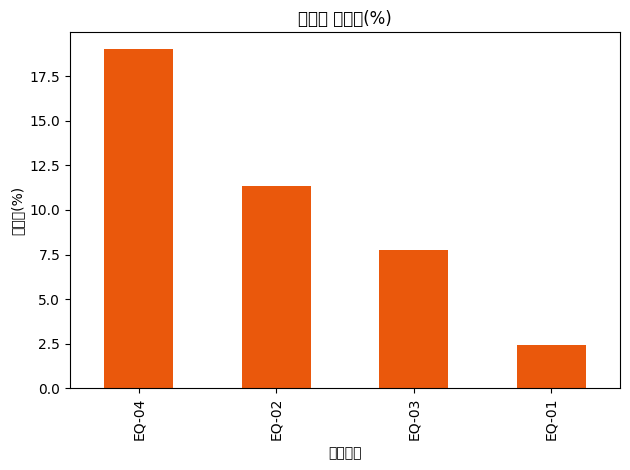

In [6]:
fail_rate.sort_values(ascending=False).plot(kind="bar", color="#ea580c")
plt.title("설비별 불량률(%)")
plt.ylabel("불량률(%)")
plt.tight_layout()
plt.show()

## 7단계. 결과 해석하기

> EQ-04의 불량률이 약 19.0%로 가장 높게 나타났다. 이는 가장 낮은 EQ-01(약 2.4%)보다 뚜렷이 높은 수치다.

## 8단계. 개선안 작성하기

> 개선 제안 1: EQ-04의 최근 정비 이력과 센서 로그를 추가로 점검한다.
> 개선 제안 2: EQ-04 생산 로트에 대해 검사 주기를 일시적으로 강화한다.

## 9단계. 분석의 한계 적어보기

> 이 분석은 상관관계를 관찰한 것이며, 해당 설비가 불량의 확정 원인이라고 단정할 수 없다.
> 정확한 원인 확인을 위해서는 추가 데이터와 현장 조사가 필요하다.

## 10단계. 발표 자료 준비하기
`lectures/week10/project-report-template.html`에 위 내용을 옮겨 적어 최종 보고서를 완성한다.